# Exposure at Default (EAD) and Adverse Selection

As always, let's start by importing our data and packages.

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
import statsmodels.api as sm
from scipy import stats
from scipy.stats import lognorm
from sklearn.metrics import roc_auc_score
warnings.simplefilter(action='ignore', category=FutureWarning)
from sklearn.datasets import make_classification
from sklearn.linear_model import LinearRegression
from scipy.optimize import curve_fit
from statsmodels.othermod.betareg import BetaModel
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tobit_reg import TobitRegression
from scipy.stats import norm
from scipy.optimize import minimize
from scipy.special import gamma, gammaln
from scipy.stats import beta
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from lifelines import CoxPHFitter



In [2]:
csvs_path = [rf'datasets/{name}.csv' for name in ['hmeq', 'lgd', 'ratings', 'mortgage']]
hmeq, lgd, ratings, mortgage = list(map(pd.read_csv, csvs_path))

pag 331

For on-balance-sheet exposures, such as term loans, installment loans, and mortgages, the EAD is defined as the nominal outstading balance, net of specific provisions. In other words, it represents the net outstading debt.

### Fixed versus Variable Outstading

The EAD is deterministic for some loans and variable for others. Within the loans with variable amount outstanding, two types may be distinguished: credit lines and loans with flexible payment schedules.

Credit lines generally have a limit and a drawn amount. The borrower can draw on the line up to the limit. At the end of a period, the borrower is required to repay the drawn amount, after which it is set back to zero.

Loans with flexible payment schedules are often loans with prepayment option and a redraw option. Amortizing loans generally require the borrowers to make interest and principal payments prior to maturity and the loan balance reduces the principal amount that is repaid. A prepayment option allows the borrower to pay down more than the scheduled amount, whereas a redraw option allows the borrower to draw on prepayment and/or principal repayments.

### Off-Balance-Sheet Exposures

Off-balance-sheet exposures include contigent credit exposures (e.g, credit guarantees and loan commitments) and counterparty credit risk in relation to over-the-counter (OTC), i.e, bilateral, derivative agreements on future deliveries. The exposure at default depends on the loss in relation to a guarantee or an adverse movement of an underlying measure in conjunction with the credit event of a counterparty in derivative contracts.

For off-balance-sheet exposures, you need to take into account what portion of the undrawn amount is likely to be converted into credit upon the default of a reference firm or person or counterparty.

### Conversion Measures

Exposures at default can be modeled directly by building a model for the exposure amount or a monotone transformation thereof. Alternatively, you may relate the EAD to a scaling variable and derive conversion measures.

| **Conversion Measure** | **Formula** |
| :--- | :--- |
| Credit Conversion Factor (CCF) | $EAD = Drawn + CCF*(Limit-Drawn)$ |
| Credit Equivalent (CEQ) | $EAD = Drawn + CEQ*Limit$ |
| Limit Conversion Factor (LCF)/Loan Equivalent (LEQ) | $EAD = LCF*Limit$ |
| Used Amount Conversion Factor (UACF) | $EAD = UACF*Drawn$ |

The CCF is defined as the portion of the undrawn amount that will be converted into credit. The CEQ is defined as the portion of the limit likely tto be converted into credit. LCF or LEQ is defined as a fraction of the limit representing the total exposure.

### Regulatory perspective on EaD

In the Basel Accord, generally the CCF approeach is used. It ranges from 0 to , correspoding with an EAD equal to the drawn amount and limit, respectivelly.

For OTC derivatives, the exposure is a combination of the current exposure and potential future exposure. In the past, the EAD for OTC derivatives was the sum of the replacement cost and the potential future exposure (PFE). PFE was determined by a multiplication of the notional amount and a look-up CCF. Under these rules, the exposure is calculated as follows

$$EAD = 1.4(RC+PFE)$$

Where

##### Replacement Cost (RC)
Replacement cost captures the immediate loss if the counterparty defaulted today and you had to close out your positions. The formula depends entirely on whether there is a margin agreement in place.

**For Unmargined Transactions:**
You simply look at the current value of the derivatives minus any independent collateral you hold.
$RC = \max(V - C, 0)$
*   **$V$ (Current Market Value):** The sum of the mark-to-market values of all derivative transactions in the netting set.
*   **$C$ (Collateral):** The haircut value of net collateral held (often referred to as Net Independent Collateral Amount, or NICA). 

**For Margined Transactions:**
Margined transactions are slightly more complex because they must account for the time it takes to close out the position and the mechanics of the margin calls.
$RC = \max(V - C, TH + MTA - NICA, 0)$
*   **$V - C$:** The current market value ($V$) minus the total collateral held ($C$, which in this case includes both Variation Margin and NICA).
*   **$TH$ (Threshold):** The positive exposure threshold before the counterparty is required to send you collateral.
*   **$MTA$ (Minimum Transfer Amount):** The minimum amount of collateral that can be transferred.
*   **$NICA$ (Net Independent Collateral Amount):** The collateral posted by the counterparty that you can keep upon default (independent of daily variation margin).

*Note: The term $(TH + MTA - NICA)$ represents the largest legal exposure you could have before a variation margin call is triggered.*


##### Potential Future Exposure (PFE)
PFE measures the potential *increase* in exposure over a 1-year time horizon (for unmargined) or over the margin period of risk (for margined). 

$PFE = \text{Multiplier} \times \text{AddOn}^{\text{aggregate}}$

**The Add-On Component:**
Calculating the aggregate AddOn  involves grouping trades within a netting set into distinct asset classes (Interest Rate, FX, Credit, Equity, Commodity). For each asset class, you:
1.  Allocate trades to specific **hedging sets** (e.g., all interest rate derivatives in USD go into one set).
2.  Calculate an **Effective Notional** amount for each trade, adjusted for its maturity factor.
3.  Apply a regulatory **Supervisory Factor** (a standardized volatility metric specific to the asset class).
4.  Apply supervisory **Correlation Factors** to allow for partial offsetting of long and short positions within the hedging set.
5.  Aggregate these across all asset classes to get the total $\text{AddOn}^{\text{aggregate}}$.

**The Multiplier Component:**
The multiplier reduces the PFE if you are holding excess collateral or if the current mark-to-market value is negative (meaning you owe them money, providing a buffer against future price swings). It is floored at 5% (0.05).

$\text{Multiplier} = \min\left(1, 0.05 + 0.95 \times \exp\left(\frac{V - C}{1.9 \times \text{AddOn}^{\text{aggregate}}}\right)\right)$
*   **$V - C$:** The net current market value minus collateral. 
*   **$\exp$:** The exponential function.
*   **$1.9$:** This comes from the formula $2 \times (1 - \text{Floor})$, where the Floor is $0.05$.

## EaD Modelling

Since EAD modeling is also exposed to default selection, models like Tobit model and the Heckman selection model may provide interesting approaches.

### Data Preprocessing

For defaulted exposures, the EAD at the moment of default can be determined. We now need to consider a period $\delta_t$ before the time of default to determine the risk factors and drawn amount. The risk factors are the variables that will be used as predictors in the CCF model. Once the drawn amount is known, the CCF can be calculated as the ratio of EAD minus the drawn amount, and the limit minus the drawn amount.

A key problem is the detemrination of the time lag between the observed exposure amount at default and the observed drawn amount and limit. Various methods to determine this time horizon exist.

#### Cohort Method

This approeach groups defaulted facilities into discrete calendar periods, for example, 12 months unless another time period would be more conservative and appropriate. It collects information about the risk factors and the drawn/undrawn amounts at the beginning of the calendar period and the drawn amount at the date of default. Data of different calendar periods can then be pooled for estimation.

#### Fixed Time Horizon Method

The fixed horizon method starts by defining a fixed time horizon, usually 12 months. It then collects information about the risk factors and drawn/undrawn amounts 12 months prior to the date of default, and the drawn amount on the date of default, regardless of the actual calendar datte on which the default occured. 

#### Variable TIme Horizon Method

The variable time horizon approach is a variant of the fixed time horizon approach whereby several reference times within a chosen time horizon are used to determine the drawn/undrawn amounts and risk factors. For example, the drawn amount upon default is compared to the drawn/undrawn amounts and risk factors one, two, three or more months before default.

In [3]:
mortgage = mortgage.sort_values(by=['id', 'time']).reset_index(drop=True)
for i in range(1, 5):
    mortgage[f'lag{i}'] = mortgage.groupby('id')['balance_time'].shift(i)
mortgage['drawn'] = mortgage['lag4']
mortgage['limit'] = mortgage['balance_orig_time']
mortgage['exposure'] = mortgage['balance_time']

# Ensures exposure and drawn amounts never exceed the original limit
mortgage['exposure'] = np.minimum(mortgage['exposure'], mortgage['limit'])
mortgage['drawn'] = np.minimum(mortgage['drawn'], mortgage['limit'])

# CCF: Handle the case where (limit - drawn) is 0 to avoid division by zero
mortgage['CCF'] = np.where(
    (mortgage['limit'] - mortgage['drawn']) == 0, 
    0, 
    (mortgage['exposure'] - mortgage['drawn']) / (mortgage['limit'] - mortgage['drawn'])
)
mortgage['CEQ'] = (mortgage['exposure'] - mortgage['drawn']) / mortgage['limit']
mortgage['LCF'] = mortgage['exposure'] / mortgage['limit']
mortgage['UACF'] = mortgage['exposure'] / mortgage['drawn']
mortgage1 = mortgage.dropna(subset=['drawn', 'limit', 'exposure']).copy()
mortgage1 = mortgage1[mortgage1['drawn'] > 0]
mortgage1 = mortgage1[mortgage1['exposure'] > 0]
summary = mortgage1[['CCF', 'CEQ', 'LCF', 'UACF']].describe(percentiles=[0.01, 0.99])
print(summary)

                CCF            CEQ            LCF           UACF
count  4.451220e+05  445122.000000  445122.000000  445122.000000
mean  -4.426486e+02      -0.015565       0.933841       0.980547
std    7.673053e+04       0.037558       0.117274       0.053819
min   -2.480684e+07      -0.996330       0.000724       0.002572
1%    -1.805023e+01      -0.129737       0.372423       0.749228
50%   -2.498858e-01      -0.009959       0.974841       0.989788
99%    1.000000e+00       0.010287       1.000000       1.010535
max    1.000000e+00       0.808156       1.000000       6.278696


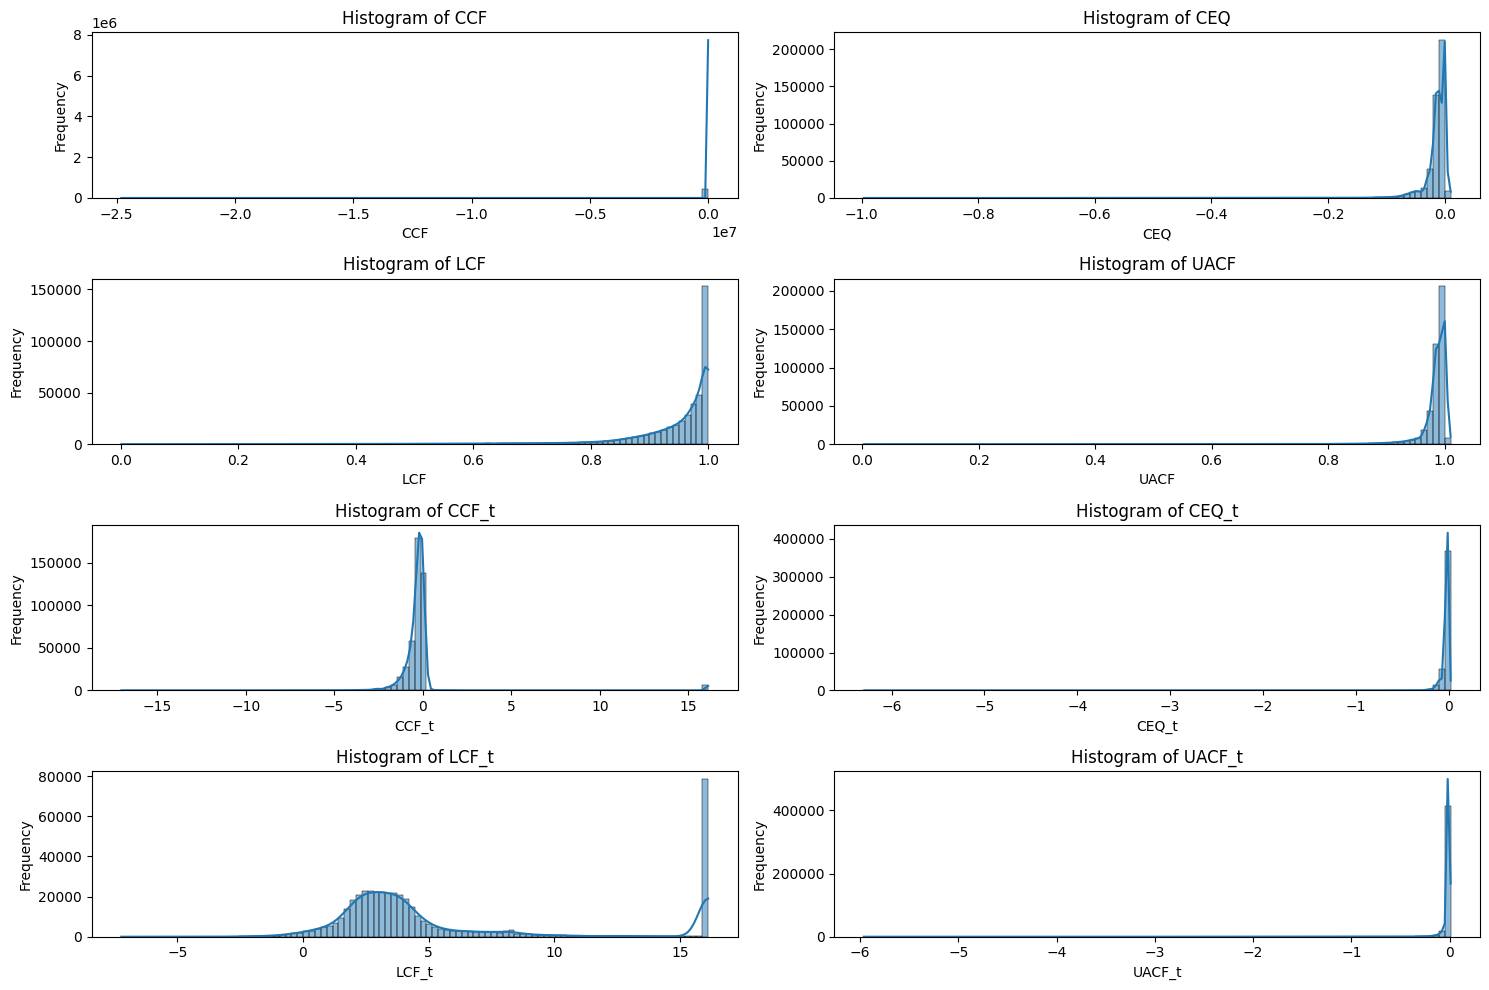

In [4]:
mortgage1['CCF'] = np.minimum(mortgage1['CCF'], 0.9999999)
mortgage1['CEQ'] = np.minimum(mortgage1['CEQ'], 0.0102912)
mortgage1['LCF'] = np.minimum(mortgage1['LCF'], 0.9999999)
mortgage1['UACF'] = np.minimum(mortgage1['UACF'], 1.0105358)
mortgage1['CCF_t'] = -np.log(1 - mortgage1['CCF'])
mortgage1['CEQ_t'] = np.log((1 + mortgage1['CEQ']) / (1 - mortgage1['CEQ']))
mortgage1['LCF_t'] = np.log(mortgage1['LCF'] / (1 - mortgage1['LCF']))
mortgage1['UACF_t'] = np.log(mortgage1['UACF'])

vars_to_plot = ['CCF', 'CEQ', 'LCF', 'UACF', 'CCF_t', 'CEQ_t', 'LCF_t', 'UACF_t']

plt.figure(figsize=(15, 10))

for i, var in enumerate(vars_to_plot, 1):
    plt.subplot(4, 2, i) 
    sns.histplot(mortgage1[var], kde=True, bins=100)
    plt.title(f'Histogram of {var}')
    plt.xlabel(var)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

#### Credit Line Models

A number of risk factors can generally be considered in EAD models:

- Facility-specific: convenant protection, utilization or LTV
- Borrower-specific: industry, geographical region, PD, credit rating, recent new loan/payoff, change in frequency of payment or prepayment
- Time density: time to default, time since origination
- Macroeconomic variables
- Commited amount, which is the advised credit limit at the start of the cohort
- The drawn amount, which is the exposure at the start of the cohort
- The undrawn amount
- The credit percentage usage, which is the exposure at the start of cohort divided by the advised credit limit at the start of the cohort
- Rating class

#### Loans with flexible payment schedules

##### Linear Regression

In [5]:
df_reg = mortgage1[mortgage1['default_time'] == 1].copy()
X = sm.add_constant(df_reg['LTV_time'])
targets = ['CCF', 'CEQ', 'LCF', 'UACF']
for target in targets:
    print(f"\n{'='*20} Regression Model: {target} {'='*20}")
    model = sm.OLS(df_reg[target], X).fit()
    print(model.summary())


==================== Regression Model: CCF ====================
                            OLS Regression Results                            
Dep. Variable:                    CCF   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.033
Date:                Sat, 21 Mar 2026   Prob (F-statistic):              0.310
Time:                        10:51:34   Log-Likelihood:            -1.0934e+05
No. Observations:               11673   AIC:                         2.187e+05
Df Residuals:                   11671   BIC:                         2.187e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------

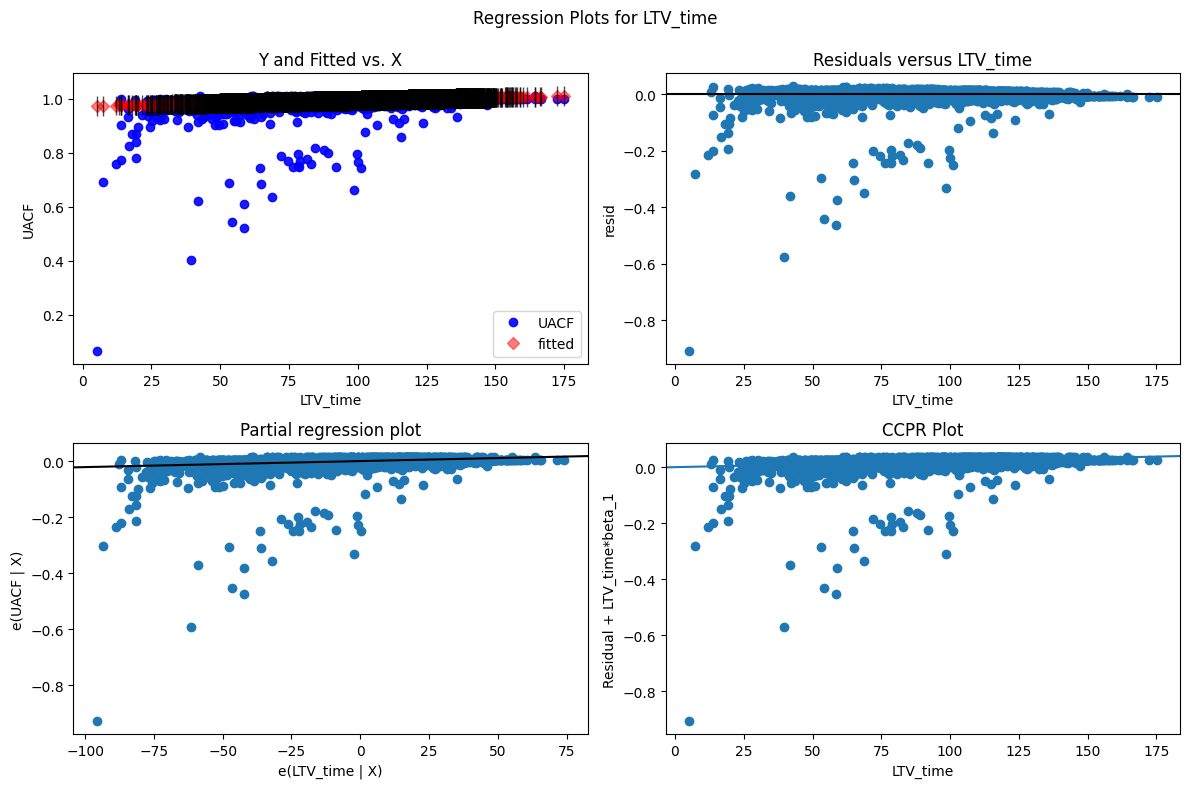

In [6]:
fig = plt.figure(figsize=(12, 8))
sm.graphics.plot_regress_exog(model, 'LTV_time', fig=fig)
plt.show()

##### Transformeed Linear Regression

In [7]:
df_transformed = mortgage1.copy()
X = sm.add_constant(df_transformed['LTV_time'])
transformed_targets = ['CCF_t', 'CEQ_t', 'LCF_t', 'UACF_t']

for target in transformed_targets:
    model = sm.OLS(df_transformed[target], X).fit()
    print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  CCF_t   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     6676.
Date:                Sat, 21 Mar 2026   Prob (F-statistic):               0.00
Time:                        10:51:35   Log-Likelihood:            -9.5392e+05
No. Observations:              445122   AIC:                         1.908e+06
Df Residuals:                  445120   BIC:                         1.908e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.9799      0.010    -94.538      0.0

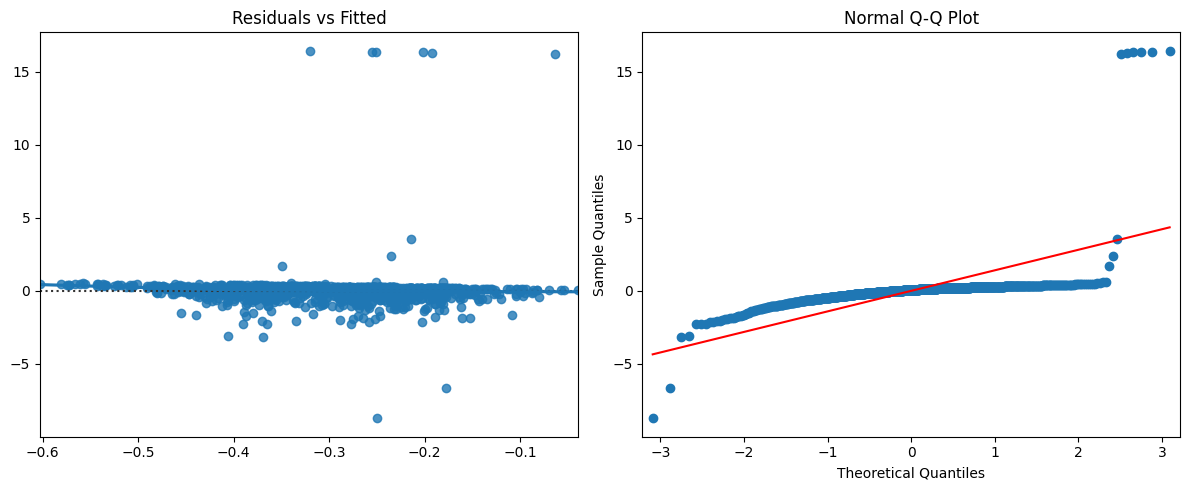

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
plot_sample = df_transformed.sample(n=1000)
sample_model = sm.OLS(plot_sample['CCF_t'], sm.add_constant(plot_sample['LTV_time'])).fit()
sns.residplot(x=sample_model.fittedvalues, y=sample_model.resid, lowess=True, ax=ax[0])
ax[0].set_title('Residuals vs Fitted')
sm.qqplot(sample_model.resid, line='s', ax=ax[1])
ax[1].set_title('Normal Q-Q Plot')
plt.tight_layout()
plt.show()

##### Beta Regression

Next to a better model fit, LCF has the benefit of the same range of values as LGD does not require a further transformation to the range of 0 to 1.



In [14]:
df_beta = mortgage1[mortgage1['default_time'] == 1].copy()
df_beta['LCF_fit'] = df_beta['LCF'].clip(lower=0.000001, upper=0.999999)
X = sm.add_constant(df_beta['LTV_time'])
model = BetaModel(df_beta['LCF_fit'], X, exog_precision=X)
results = model.fit()
print(results.summary())

                              BetaModel Results                               
Dep. Variable:                LCF_fit   Log-Likelihood:                 55693.
Model:                      BetaModel   AIC:                        -1.114e+05
Method:            Maximum Likelihood   BIC:                        -1.113e+05
Date:                Sat, 21 Mar 2026                                         
Time:                        11:01:28                                         
No. Observations:               11673                                         
Df Residuals:                   11669                                         
Df Model:                           2                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.7635      0.069     11.013      0.000       0.628       0.899
LTV_time               0.033

<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
C:\Users\guilh\AppData\Local\Temp\ipykernel_25332\1160635691.py:15: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(ltv_range, mu_pred, color='red', lw=2, label='Predicted Mean ($\mu$)')


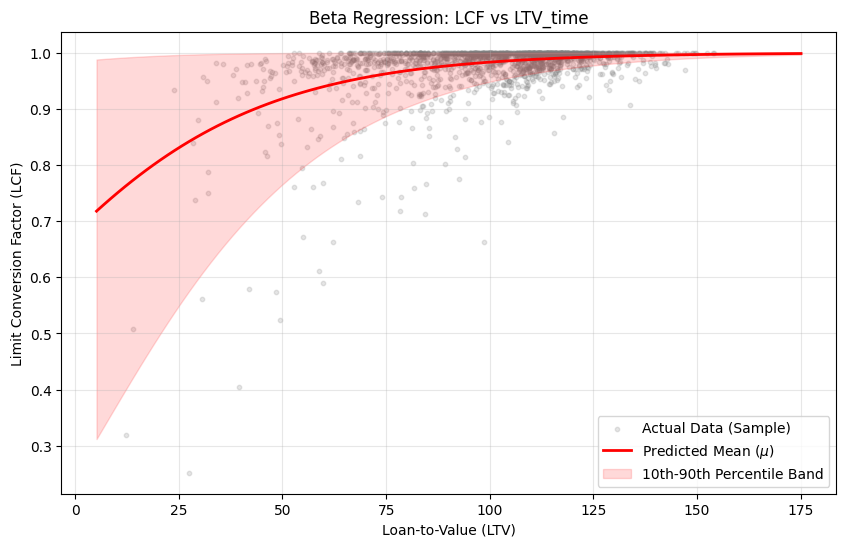

In [16]:
ltv_range = np.linspace(df_beta['LTV_time'].min(), df_beta['LTV_time'].max(), 100)
X_new = sm.add_constant(ltv_range)
params_mean = results.params[:2]      # [intercept, ltv_coeff]
params_prec = results.params[2:]      # [precision_intercept, precision_ltv_coeff]
mu_pred = 1 / (1 + np.exp(-np.dot(X_new, params_mean)))
phi_pred = np.exp(np.dot(X_new, params_prec))
alpha_p = mu_pred * phi_pred
beta_p = (1 - mu_pred) * phi_pred
lower_bound = beta.ppf(0.10, alpha_p, beta_p)
upper_bound = beta.ppf(0.90, alpha_p, beta_p)
plt.figure(figsize=(10, 6))
sample_df = df_beta.sample(n=min(len(df_beta), 2000))
plt.scatter(sample_df['LTV_time'], sample_df['LCF'], 
            alpha=0.2, s=10, color='gray', label='Actual Data (Sample)')
plt.plot(ltv_range, mu_pred, color='red', lw=2, label='Predicted Mean ($\mu$)')
plt.fill_between(ltv_range, lower_bound, upper_bound, 
                 color='red', alpha=0.15, label='10th-90th Percentile Band')
plt.title('Beta Regression: LCF vs LTV_time')
plt.xlabel('Loan-to-Value (LTV)')
plt.ylabel('Limit Conversion Factor (LCF)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Controlling for Adverse Selection in PD Models

#### Interation of PD and LGD

Generally speaking, low-risk borrowers are more likely to reduce the loan balance below the expected or scheduled balance, while high-risk borrowers are more likely to increase the loan balance above the expected balance. In other words, exposures generally increase in the case of default. Another important aspect for mortgage leding is that borrowers typically have a prepayment option, which they generally exercise if they are low risk and have axcess cash to repay the mortgage loan. Prepayment has a limited impact and can be controlled for by a separate risk factor. However, after the complete mortgage has been paid off, low-risk borrowers leave the observed population, while high-risk mortage borrowers remain. It is common in such situations to model the competing states default, payoff, and nondefault/nonpayoff by the following status:

$$S_{it} = \begin{cases} 1 & \text{borrower } i \text{ defaults at time } t \\ 2 & \text{borrower } i \text{ pays loan off at time } t \\ 0 & \text{otherwise} \end{cases}$$

To account for this, you may consider a discrete-time hazard model such as the multinomial logit or probit model, or a continuous-time hazard model (compare Deng, Quigley, and Van Order 2000).


#### Discrete Time Hazard Models

The first option is a multinomial logit (or probit) model that is a representative of the class of discrete-time hazard models as follows:

$$P(S_{it} = s|x_{it-1}) = \frac{exp(\beta'_sx_{it-1})}{1+\sum^2_{s=1}exp(\beta'_sx_{it-1})}$$

In [18]:
y = mortgage1['status_time']
X = mortgage1[['FICO_orig_time', 'LTV_time', 'gdp_time']]
X = sm.add_constant(X)
model = sm.MNLogit(y, X)
results = model.fit()
print(results.summary())
probabilities = results.predict(X)
print(probabilities.head())

Optimization terminated successfully.
         Current function value: 0.257880
         Iterations 7
                          MNLogit Regression Results                          
Dep. Variable:            status_time   No. Observations:               445122
Model:                        MNLogit   Df Residuals:                   445114
Method:                           MLE   Df Model:                            6
Date:                Sat, 21 Mar 2026   Pseudo R-squ.:                 0.03654
Time:                        11:17:35   Log-Likelihood:            -1.1479e+05
converged:                       True   LL-Null:                   -1.1914e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
 status_time=1       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -2.1234      0.097    -21.984      0.000      -2.313      -1.934
FICO_orig_time   

Overall Accuracy: 94.01%

Classification Report:


d:\projects\cra_mtae_sas_in_py\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\projects\cra_mtae_sas_in_py\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

           0       0.94      1.00      0.97    418471
           1       0.00      0.00      0.00     11673
           2       0.00      0.00      0.00     14978

    accuracy                           0.94    445122
   macro avg       0.31      0.33      0.32    445122
weighted avg       0.88      0.94      0.91    445122



d:\projects\cra_mtae_sas_in_py\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


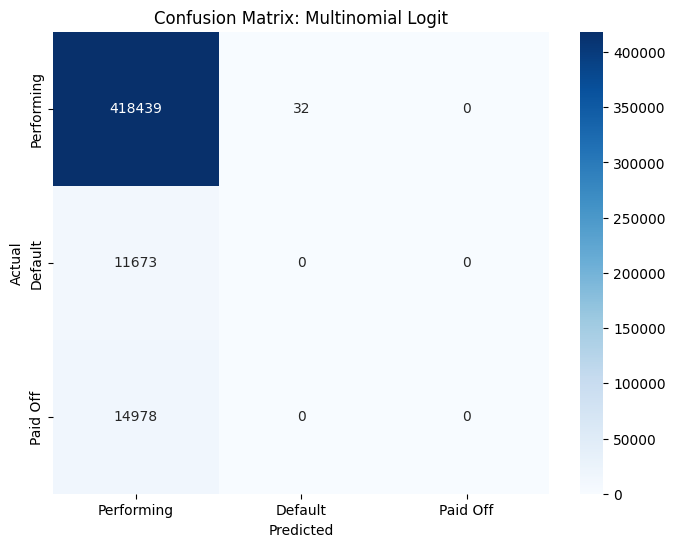

In [20]:
y_pred_probs = results.predict(X)
y_pred = y_pred_probs.idxmax(axis=1)
print(f"Overall Accuracy: {accuracy_score(y, y_pred):.2%}")
print("\nClassification Report:")
print(classification_report(y, y_pred))
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Performing', 'Default', 'Paid Off'],
            yticklabels=['Performing', 'Default', 'Paid Off'])
plt.title('Confusion Matrix: Multinomial Logit')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

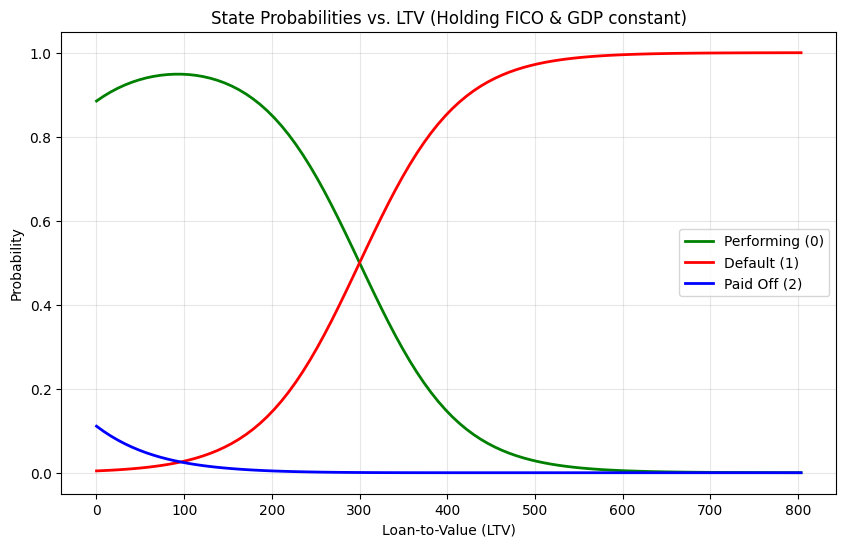

In [21]:
ltv_plot_range = np.linspace(X['LTV_time'].min(), X['LTV_time'].max(), 100)
X_viz = pd.DataFrame({
    'const': 1,
    'FICO_orig_time': X['FICO_orig_time'].mean(),
    'LTV_time': ltv_plot_range,
    'gdp_time': X['gdp_time'].mean()
})
viz_probs = results.predict(X_viz)
plt.figure(figsize=(10, 6))
plt.plot(ltv_plot_range, viz_probs[0], label='Performing (0)', color='green', lw=2)
plt.plot(ltv_plot_range, viz_probs[1], label='Default (1)', color='red', lw=2)
plt.plot(ltv_plot_range, viz_probs[2], label='Paid Off (2)', color='blue', lw=2)

plt.title('State Probabilities vs. LTV (Holding FICO & GDP constant)')
plt.xlabel('Loan-to-Value (LTV)')
plt.ylabel('Probability')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

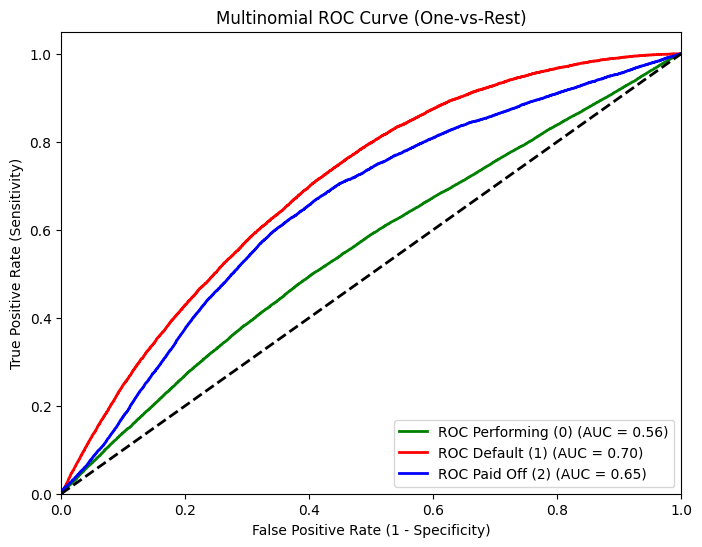

In [23]:
y_bin = label_binarize(y, classes=[0, 1, 2])
n_classes = y_bin.shape[1]
y_score = results.predict(X).values 
fpr = dict()
tpr = dict()
roc_auc = dict()
class_names = ['Performing (0)', 'Default (1)', 'Paid Off (2)']

plt.figure(figsize=(8, 6))
colors = ['green', 'red', 'blue']

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
             label=f'ROC {class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Multinomial ROC Curve (One-vs-Rest)')
plt.legend(loc="lower right")
plt.show()

We obtain two parameter estimates for every covariable. FICO decreases the probabilities of default and payoff. LTV increases the probability of default but decreases the probability of payoff. GDP growth decreases the probability of default and increases probability of payoff.

Since our AUC is 0.7 for default, it means that there's a 70% chance the model correcly gave the defaulter a higher risk score. Our prepayment prediction (paid off) on the other hand it's quite mediocre while our performing is rather poor, as it's almost a random guess.

#### Estimation of Default Probabilities

The probabilities of default can be estimated as follows:

$$ \hat{P}(S_{it} = 1 | \mathbf{x}_{it-1}) = \frac{\exp(\hat{\boldsymbol{\beta}}_1' \mathbf{x}_{it-1})}{1 + \exp(\hat{\boldsymbol{\beta}}_1' \mathbf{x}_{it-1}) + \exp(\hat{\boldsymbol{\beta}}_2' \mathbf{x}_{it-1})} $$

with

$$ \hat{\boldsymbol{\beta}}_1' \mathbf{x}_{it-1} = \hat{\beta}_{0,1} + \hat{\beta}_{1,1} \cdot \text{FICO\_orig\_time} + \hat{\beta}_{2,1} \cdot \text{LTV\_time} + \hat{\beta}_{3,1} \cdot \text{gdp\_time} $$

$$ \hat{\boldsymbol{\beta}}_2' \mathbf{x}_{it-1} = \hat{\beta}_{0,2} + \hat{\beta}_{1,2} \cdot \text{FICO\_orig\_time} + \hat{\beta}_{2,2} \cdot \text{LTV\_time} + \hat{\beta}_{3,2} \cdot \text{gdp\_time} $$

Overall Actual Default Rate: 0.02435
Overall Predicted PD: 0.02622


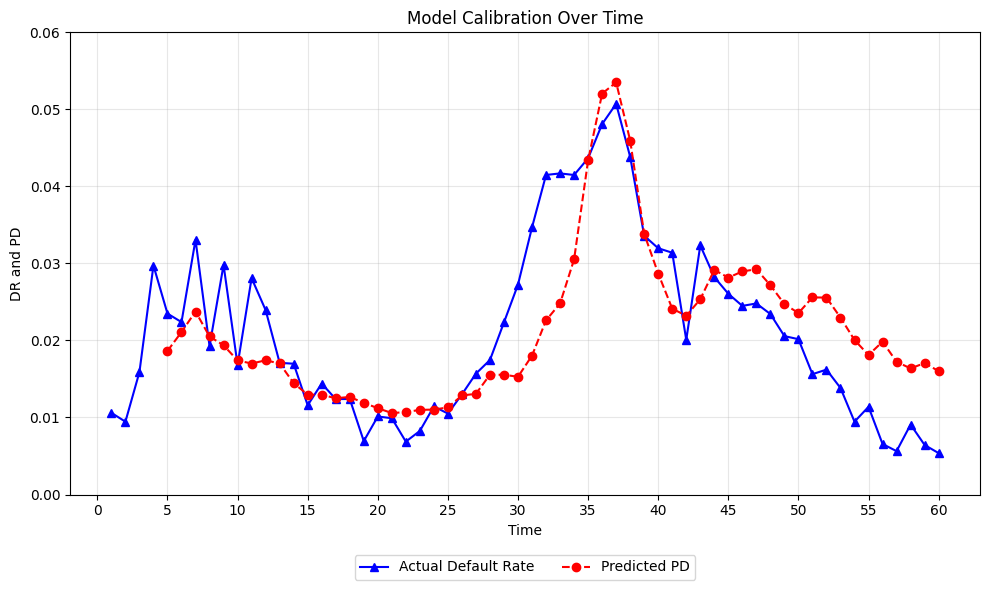

In [28]:
actual_mean = (mortgage['status_time'] == 1).mean()
predicted_mean = probabilities[1].mean()
print(f"Overall Actual Default Rate: {actual_mean:.5f}")
print(f"Overall Predicted PD: {predicted_mean:.5f}")
calibration_df = pd.DataFrame({
    'time': mortgage['time'],
    'actual_default': (mortgage['status_time'] == 1).astype(int),
    'predicted_pd': probabilities[1]
})

means_by_time = calibration_df.groupby('time').mean().reset_index()


plt.figure(figsize=(10, 6))
plt.plot(means_by_time['time'], means_by_time['actual_default'], 
         label='Actual Default Rate', color='blue', marker='^', linestyle='-')
plt.plot(means_by_time['time'], means_by_time['predicted_pd'], 
         label='Predicted PD', color='red', marker='o', linestyle='--')
plt.ylim(0, 0.06)
plt.xticks(range(0, 61, 5))
plt.xlabel('Time')
plt.ylabel('DR and PD')
plt.title('Model Calibration Over Time')
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=2)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##### Estimation of Payoff Probabilities

Similarly, the probabilities of payoff can be estimated as:

$$ \hat{P}(S_{it} = 2 | \mathbf{x}_{it-1}) = \frac{\exp(\hat{\boldsymbol{\beta}}_2' \mathbf{x}_{it-1})}{1 + \exp(\hat{\boldsymbol{\beta}}_1' \mathbf{x}_{it-1}) + \exp(\hat{\boldsymbol{\beta}}_2' \mathbf{x}_{it-1})} $$

with

$$ \hat{\boldsymbol{\beta}}_1' \mathbf{x}_{it-1} = \hat{\beta}_{0,1} + \hat{\beta}_{1,1} \cdot \text{FICO\_orig\_time} + \hat{\beta}_{2,1} \cdot \text{LTV\_time} + \hat{\beta}_{3,1} \cdot \text{gdp\_time} $$

$$ \hat{\boldsymbol{\beta}}_2' \mathbf{x}_{it-1} = \hat{\beta}_{0,2} + \hat{\beta}_{1,2} \cdot \text{FICO\_orig\_time} + \hat{\beta}_{2,2} \cdot \text{LTV\_time} + \hat{\beta}_{3,2} \cdot \text{gdp\_time} $$

Global Actual Payoff Rate: 0.04271
Global Predicted Payoff Prob: 0.03365


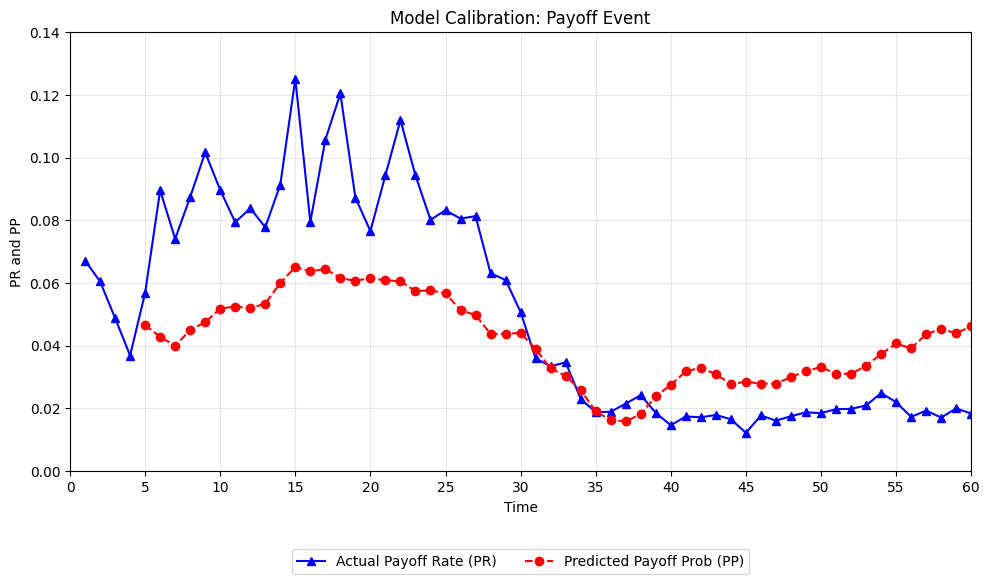

In [31]:
calibration_payoff = pd.DataFrame({
    'time': mortgage['time'],
    'actual_payoff': (mortgage['status_time'] == 2).astype(int),
    'predicted_pp': probabilities[2] # Probability of State 2
})
global_actual_pr = calibration_payoff['actual_payoff'].mean()
global_predicted_pp = calibration_payoff['predicted_pp'].mean()

print(f"Global Actual Payoff Rate: {global_actual_pr:.5f}")
print(f"Global Predicted Payoff Prob: {global_predicted_pp:.5f}")
means_payoff_time = calibration_payoff.groupby('time').mean().reset_index()

plt.figure(figsize=(10, 6))
plt.plot(means_payoff_time['time'], means_payoff_time['actual_payoff'], 
         label='Actual Payoff Rate (PR)', color='blue', marker='^', markersize=6)
plt.plot(means_payoff_time['time'], means_payoff_time['predicted_pp'], 
         label='Predicted Payoff Prob (PP)', color='red', marker='o', markersize=6, linestyle='--')
plt.ylim(0, 0.14)
plt.xlim(0, 60)
plt.xticks(range(0, 61, 5))
plt.yticks([i/100 for i in range(0, 15, 2)]) # 0 to 0.14 by 0.02
plt.xlabel('Time')
plt.ylabel('PR and PP')
plt.title('Model Calibration: Payoff Event')
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=2)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Continuos-Time Hazard Models


In [36]:
# time2 measures how long the loan was "at risk"
lifetest_df = mortgage.sort_values(by=['id', 'time'])
lifetest_df['time2'] = lifetest_df['time'] - lifetest_df['first_time'] + 1
lifetest_df['is_last'] = ~lifetest_df.duplicated(subset='id', keep='last')
# We keep rows where an event (1 or 2) happened OR it's the last time we saw the loan
terminal_mask = (lifetest_df['is_last']) | (lifetest_df['status_time'].isin([1, 2]))
lifetest_temp2 = lifetest_df[terminal_mask]
# This ensures that if a loan defaults at time 10, we ignore any extra rows at 11 or 12
lifetest_final = lifetest_temp2.groupby('id').head(1).copy()
# Event = 1 (Default). Everything else (0, 2) is Censored.
lifetest_final['default_event'] = (lifetest_final['status_time'] == 1).astype(int)
df_cox = lifetest_final[['time2', 'default_event', 'FICO_orig_time', 'LTV_orig_time']].dropna()

cph = CoxPHFitter()
cph.fit(df_cox, duration_col='time2', event_col='default_event')
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 50000 total observations, 34846 right-censored observations>
             duration col = 'time2'
                event col = 'default_event'
      baseline estimation = breslow
   number of observations = 50000
number of events observed = 15154
   partial log-likelihood = -150534.32
         time fit was run = 2026-03-21 15:33:05 UTC

---
                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                       
FICO_orig_time -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
LTV_orig_time   0.02      1.02      0.00            0.01            0.02                1.01                1.02

                cmp to      z      p  -log2(p)
covariate                                     
FICO_orig_time    0.00 -39.64 <0.005       inf
LTV_orig_time     0.00  19.38 <0.005    275.57
---
Concordance = 0.63
Partial AIC = 301072.64
log-likelihood ratio test = 2164.11 on 2 df
-log2(p) of ll-ratio test = inf

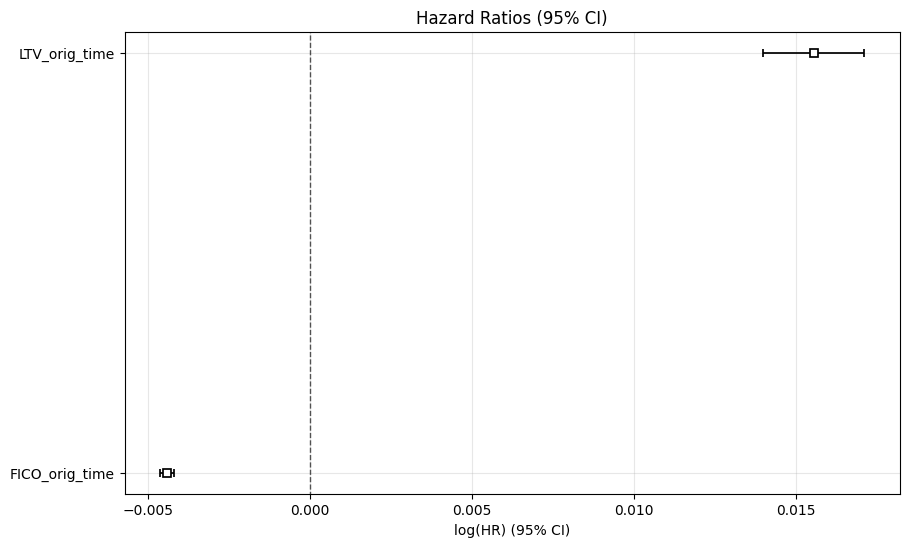

In [37]:
plt.figure(figsize=(10, 6))
cph.plot()
plt.title('Hazard Ratios (95% CI)')
plt.grid(True, alpha=0.3)
plt.show()

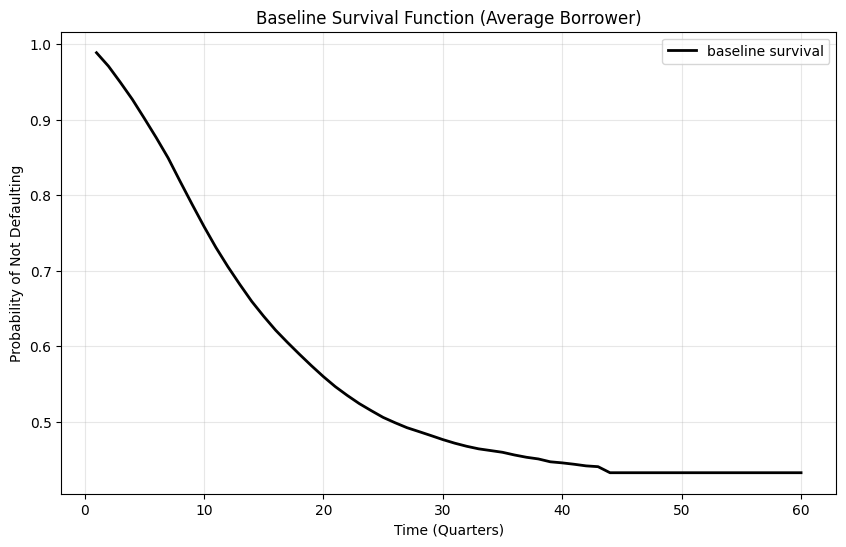

In [ ]:
plt.figure(figsize=(10, 6))
cph.baseline_survival_.plot(ax=plt.gca(), color='black', lw=2)
plt.title('Baseline Survival Function (Average Borrower)')
plt.xlabel('Time (Quarters)')
plt.ylabel('Probability of Not Defaulting')
plt.grid(True, alpha=0.3)
plt.show()

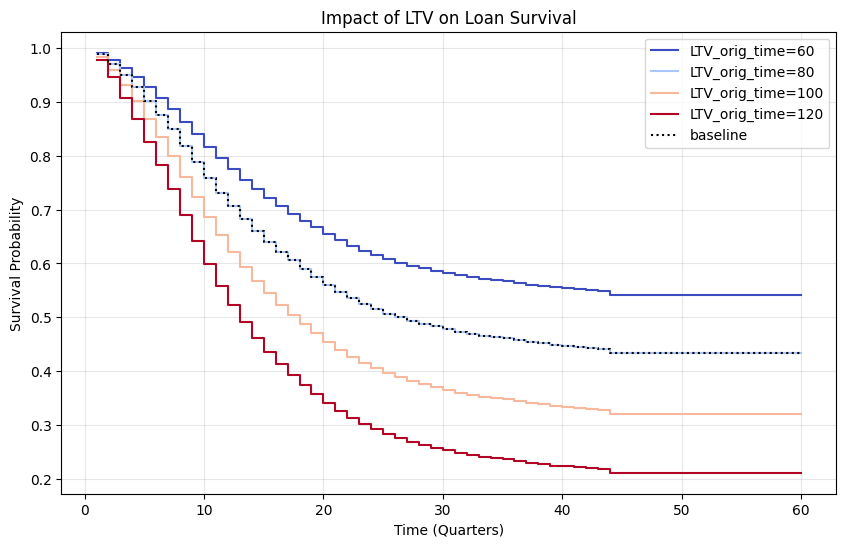

In [41]:
cph.plot_partial_effects_on_outcome(
    covariates='LTV_orig_time', 
    values=[60, 80, 100, 120], 
    cmap='coolwarm',
    figsize=(10, 6) 
)
plt.title('Impact of LTV on Loan Survival')
plt.xlabel('Time (Quarters)')
plt.ylabel('Survival Probability')
plt.grid(True, alpha=0.3)
plt.show()

#### Extensions

Other ways to control for adverse selection include bivariate probit models, estimation of the ivnerse Mills ratio in a first-stage probit model for the payoff event and control for the inverse Mills ratio in a second-stage probit model for the default event, and the continued observation of paid-off borrower.